# Setup

## OpenAI Key 등록
- [OpenAI Key 발급](https://platform.openai.com/api-keys)
- [OpenAI 요금](https://openai.com/api/pricing/)

In [1]:
from dotenv import load_dotenv

load_dotenv()


True

# Vector DB

## Loader

In [2]:
from langchain.document_loaders import TextLoader

file_path = "./data/rag-keywords.txt"
loader = TextLoader(file_path, encoding='utf-8')

docs = loader.load()
print(f"로드된 파일의 수: {len(docs)}")

로드된 파일의 수: 1


## Splitter

In [3]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=0)

In [4]:
split_doc1 = text_splitter.split_documents(docs)
print(f"분리된 문서의 수: {len(split_doc1)}")

분리된 문서의 수: 11


## Embedding

In [5]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

## ChromaDB

In [6]:
from langchain_community.vectorstores import Chroma

vectorstore = Chroma.from_documents(
    documents=split_doc1, # 문서 리스트
    embedding=embeddings, # 임베딩 함수
    collection_name="rag_keywords", # 컬렉션 이름
    persist_directory="./chroma_rag_keywords" # 영구 저장 경로
)

print("파일이 Chroma VectorStore에 저장되었습니다.")

파일이 Chroma VectorStore에 저장되었습니다.


# [Retriever](https://python.langchain.com/docs/how_to/#retrievers)
- Retrieval Augmented Generation (RAG)에서 `검색도구(Retrievers)` 는 벡터 저장소에서 문서를 검색하는 도구입니다.
- LangChain은 간단한 의미 검색도구부터 성능 향상을 위해 고려된 다양한 검색 알고리즘을 지원합니다.

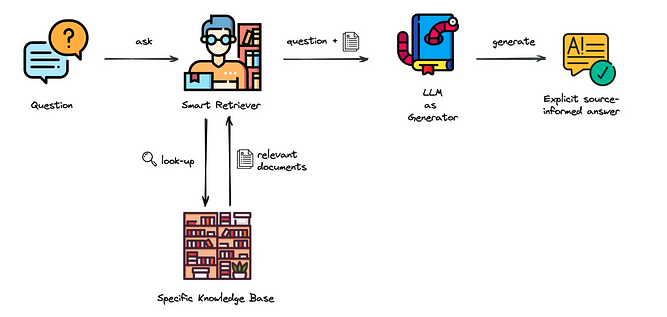

## Retriever 생성

In [7]:
# 데이터베이스를 검색기로 사용하기 위해 retriever 변수에 할당
retriever = vectorstore.as_retriever()

## [OpenAI LLM](https://platform.openai.com/docs/deprecations)

In [8]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

## [문맥 압축 검색기](https://wikidocs.net/234097)
- 검색 시스템에서 직면하는 어려움 중 하나는 데이터를 시스템에 수집할 때 어떤 특정 질의를 처리해야 할지 미리 알 수 없다는 점입니다.
- 이는 질의와 가장 관련성이 높은 정보가 많은 양의 무관한 텍스트를 포함한 문서에 묻혀 있을 수 있음을 의미합니다.
- 이러한 전체 문서를 애플리케이션에 전달하면 더 비용이 많이 드는 LLM 호출과 품질이 낮은 응답으로 이어질 수 있습니다.
- `ContextualCompressionRetriever` 은 이 문제를 해결하기 위해 고안되었습니다.
- 아이디어는 간단합니다. 검색된 문서를 그대로 즉시 반환하는 대신, 주어진 질의의 맥락을 사용하여 문서를 압축함으로써 관련 정보만 반환되도록 할 수 있습니다.
- 여기서 "압축"은 개별 문서의 내용을 압축하는 것과 문서를 전체적으로 필터링하는 것 모두를 의미합니다.

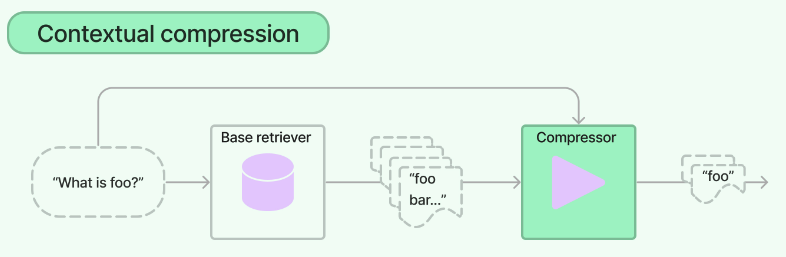

### 1. LLMChainExtractor
- `LLMChainExtractor`는 `LLM을 이용해` 체인(chain) 형태로 문서에서 질문과 관련된 `핵심 부분만 추출(extract)` 하는 클래스입니다.

In [9]:
from langchain.retrievers.document_compressors import LLMChainExtractor

llm_extract = LLMChainExtractor.from_llm(llm)

- `ContextualCompressionRetriever`는 `retriever` + `compressor` 를 결합한 하이브리드 리트리버입니다.

즉, 기존 retriever가 관련 문서(문맥) 를 찾고, LLM 등을 이용해 불필요한 부분을 압축(요약) 하는 과정을 자동으로 연결합니다.

In [10]:
from langchain.retrievers import ContextualCompressionRetriever

compression_retriever = ContextualCompressionRetriever(
    base_compressor=llm_extract, base_retriever=retriever
)

In [11]:
# 관련 문서를 검색합니다.
docs = compression_retriever.invoke("TF IDF 에 대하여 알려줘")

# 관련 문서를 검색
for doc in docs:
    print(doc.page_content)
    print("=========================================================")


정义: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: 많은 문서에서 자주 등장하지 않는 단어는 높은 TF-IDF 값을 가집니다.
연관키워드: 자연어 처리, 정보 검색, 데이터 마이닝


### 2. LLMChainFilter
- `LLMChainFilter`는 `LLM`을 이용해 각 문서가 질문(query)과 `관련이 있는지 여부만 판단`하고, `관련 있으면 그대로 유지`하고, `관련 없으면 제거`하는 이진 필터(binary filter) 입니다.

In [12]:
from langchain.retrievers.document_compressors import LLMChainFilter

llm_filter = LLMChainFilter.from_llm(llm)

- `ContextualCompressionRetriever`는 `retriever` + `compressor` 를 결합한 하이브리드 리트리버입니다.

즉, 기존 retriever가 관련 문서(문맥) 를 찾고, LLM 등을 이용해 불필요한 부분을 압축(요약) 하는 과정을 자동으로 연결합니다.

In [13]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=llm_filter, base_retriever=retriever
)


In [14]:
# 관련 문서를 검색합니다.
docs = compression_retriever.invoke("TF IDF 에 대하여 알려줘")

# 관련 문서를 검색
for doc in docs:
    print(doc.page_content)
    print("=========================================================")

정의: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: 많은 문서에서 자주 등장하지 않는 단어는 높은 TF-IDF 값을 가집니다.
연관키워드: 자연어 처리, 정보 검색, 데이터 마이닝

Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.
예시: 이미지 인식, 음성 인식, 자연어 처리 등에서 딥러닝 모델이 활용됩니다.
연관키워드: 인공신경망, 머신러닝, 데이터 분석

Schema

정의: 스키마는 데이터베이스나 파일의 구조를 정의하는 것으로, 데이터가 어떻게 저장되고 조직되는지에 대한 청사진을 제공합니다.
예시: 관계형 데이터베이스의 테이블 스키마는 열 이름, 데이터 타입, 키 제약 조건 등을 정의합니다.
연관키워드: 데이터베이스, 데이터 모델링, 데이터 관리

DataFrame
정의: 오픈 소스는 소스 코드가 공개되어 누구나 자유롭게 사용, 수정, 배포할 수 있는 소프트웨어를 의미합니다. 이는 협업과 혁신을 촉진하는 데 중요한 역할을 합니다.
예시: 리눅스 운영 체제는 대표적인 오픈 소스 프로젝트입니다.
연관키워드: 소프트웨어 개발, 커뮤니티, 기술 협업

Structured Data

정의: 구조화된 데이터는 정해진 형식이나 스키마에 따라 조직된 데이터입니다. 이는 데이터베이스, 스프레드시트 등에서 쉽게 검색하고 분석할 수 있습니다.
예시: 관계형 데이터베이스에 저장된 고객 정보 테이블은 구조화된 데이터의 예입니다.
연관키워드: 데이터베이스, 데이터 분석, 데이터 모델링

Parser

정의: 파서는 주어진 데이터(문자열, 파일 등)를 분석하여 구조화된 형태로 변환하는 도구입니다. 이는 프로그래밍 언어의 구문 분석이나 파일 데이터 처리에 사용됩니다.
예시: HTML 문서를 구문 분석하여 웹 페이지의 DOM 구조를 생

### 3. EmbeddingsFilter


In [15]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

- `EmbeddingsFilter`는 질문(query) 과 문서(document) 의 임베딩(embedding) `유사도를 계산해서 관련성이 낮은 문서(혹은 문장)를 자동으로 걸러내는 문서 필터`입니다.

즉, LLM을 호출하지 않고, 수학적으로(similarity) "질문과 얼마나 비슷한가"를 기준으로 압축합니다.

In [16]:
from langchain.retrievers.document_compressors import EmbeddingsFilter

embeddings_filter = EmbeddingsFilter(embeddings=embeddings, similarity_threshold=0.3)

- `ContextualCompressionRetriever`는 `retriever` + `compressor` 를 결합한 하이브리드 리트리버입니다.

즉, 기존 retriever가 관련 문서(문맥) 를 찾고, LLM 등을 이용해 불필요한 부분을 압축(요약) 하는 과정을 자동으로 연결합니다.

In [17]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=embeddings_filter, base_retriever=retriever
)

In [18]:
# 관련 문서를 검색합니다.
docs = compression_retriever.invoke("TF IDF 에 대하여 알려줘")

# 관련 문서를 검색
for doc in docs:
    print(doc.page_content)
    print("=========================================================")


정의: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: 많은 문서에서 자주 등장하지 않는 단어는 높은 TF-IDF 값을 가집니다.
연관키워드: 자연어 처리, 정보 검색, 데이터 마이닝

Deep Learning

정의: 딥러닝은 인공신경망을 이용하여 복잡한 문제를 해결하는 머신러닝의 한 분야입니다. 이는 데이터에서 고수준의 표현을 학습하는 데 중점을 둡니다.
예시: 이미지 인식, 음성 인식, 자연어 처리 등에서 딥러닝 모델이 활용됩니다.
연관키워드: 인공신경망, 머신러닝, 데이터 분석

Schema

정의: 스키마는 데이터베이스나 파일의 구조를 정의하는 것으로, 데이터가 어떻게 저장되고 조직되는지에 대한 청사진을 제공합니다.
예시: 관계형 데이터베이스의 테이블 스키마는 열 이름, 데이터 타입, 키 제약 조건 등을 정의합니다.
연관키워드: 데이터베이스, 데이터 모델링, 데이터 관리

DataFrame


### 4. DocumentCompressorPipeline


- `LLMChainExtractor`는 `LLM을 이용해` 체인(chain) 형태로 문서에서 질문과 관련된 `핵심 부분만 추출(extract)` 하는 클래스입니다.

In [19]:
from langchain.retrievers.document_compressors import LLMChainExtractor

llm_extract = LLMChainExtractor.from_llm(llm)

- `LLMChainFilter`는 `LLM`을 이용해 각 문서가 질문(query)과 `관련이 있는지 여부만 판단`하고, `관련 있으면 그대로 유지`하고, `관련 없으면 제거`하는 이진 필터(binary filter) 입니다.

In [20]:
from langchain.retrievers.document_compressors import LLMChainFilter

llm_filter = LLMChainFilter.from_llm(llm)

- `EmbeddingsFilter`는 질문(query) 과 문서(document) 의 임베딩(embedding) `유사도를 계산해서 관련성이 낮은 문서(혹은 문장)를 자동으로 걸러내는 문서 필터`입니다.

즉, LLM을 호출하지 않고, 수학적으로(similarity) "질문과 얼마나 비슷한가"를 기준으로 압축합니다.

In [21]:
from langchain.retrievers.document_compressors import EmbeddingsFilter
from langchain_openai import OpenAIEmbeddings

embeddings_filter = EmbeddingsFilter(
    embeddings=OpenAIEmbeddings(model="text-embedding-3-small"), similarity_threshold=0.3)

- `DocumentCompressorPipeline`은 `여러 개의 "문서 압축기(Document Compressor)"를 순서대로 연결(Sequentially Chained)하여 문서를 단계적으로 압축(compress)`할 수 있게 하는 조합형(Composite) 압축기입니다.

즉, 단일 압축기 (LLMChainExtractor, EmbeddingsFilter)는 한 단계만 수행하지만, `DocumentCompressorPipeline은
여러 압축기를 순서대로 적용`합니다.

In [22]:
from langchain.retrievers.document_compressors import DocumentCompressorPipeline

pipeline_compressor = DocumentCompressorPipeline(
    transformers=[llm_extract, llm_filter, embeddings_filter]
)

- `ContextualCompressionRetriever`는 `retriever` + `compressor` 를 결합한 하이브리드 리트리버입니다.

즉, 기존 retriever가 관련 문서(문맥) 를 찾고, LLM 등을 이용해 불필요한 부분을 압축(요약) 하는 과정을 자동으로 연결합니다.

In [23]:
compression_retriever = ContextualCompressionRetriever(
    base_compressor=pipeline_compressor, base_retriever=retriever
)

In [24]:
# 관련 문서를 검색합니다.
docs = compression_retriever.invoke("TF IDF 에 대하여 알려줘")

# 관련 문서를 검색
for doc in docs:
    print(doc.page_content)
    print("=========================================================")

TF-IDF (Term Frequency-Inverse Document Frequency)
정의: TF-IDF는 문서 내에서 단어의 중요도를 평가하는 데 사용되는 통계적 척도입니다. 이는 문서 내 단어의 빈도와 전체 문서 집합에서 그 단어의 희소성을 고려합니다.
예시: 많은 문서에서 자주 등장하지 않는 단어는 높은 TF-IDF 값을 가집니다.
연관키워드: 자연어 처리, 정보 검색, 데이터 마이닝


## 간단한 RAG 예제

### PromptTemplate

In [25]:
from langchain.prompts import PromptTemplate

prompt_template = """
    다음 문서를 바탕으로 질문에 답변해주세요.
    
    문서:
    {context}
    
    질문: {question}
    
    답변: 문서의 내용을 바탕으로 정확하고 자세하게 답변해주세요.
"""
    
prompt = PromptTemplate.from_template(
    template=prompt_template
)

### LLM

In [26]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### RetrievalQA

In [ ]:
from langchain.chains import RetrievalQA

# RAG (Retrieval-Augmented Generation) 시스템 생성
rag_system = RetrievalQA.from_chain_type(
    llm=llm,  # 사용할 LLM 모델 (예: ChatOpenAI, ChatAnthropic 등)
    
    chain_type="stuff",  # 문서 처리 방식: "stuff"는 검색된 모든 문서를 한번에 LLM에 전달
                         # 다른 옵션: "map_reduce", "refine", "map_rerank"
    
    retriever=compression_retriever, # 문맥 압축 검색기 적용 
    
    return_source_documents=True,  # 답변과 함께 참조한 원본 문서도 반환 (출처 확인 가능)
    
    chain_type_kwargs={"prompt": prompt}  # 커스텀 프롬프트 템플릿 적용
)

In [31]:
def test_rag_system(rag_system, questions):
    """RAG 시스템을 테스트하는 함수"""
    for question in questions:
        print(f"\n질문: {question}")
        
        # 검색된 문서들 가져오기
        retriever = rag_system.retriever # RAG 시스템의 검색기
        docs = retriever.invoke(question) # 관련 문서 검색
        
        print("관련 문서:")
        for i, doc in enumerate(docs, 1):
            print(f"{i}. {doc.page_content[:100]}...")
        
        print("=" * 50)

In [32]:
# 테스트 질문들
test_questions = [
    "벡터 데이터베이스의 역할은 무엇인가요?"
]

test_rag_system(rag_system, test_questions)


질문: 벡터 데이터베이스의 역할은 무엇인가요?
관련 문서:
1. Extracted relevant parts:
VectorStore

정의: 벡터스토어는 벡터 형식으로 변환된 데이터를 저장하는 시스템입니다. 이는 검색, 분류 및 기타 데이터 분...
